In [1]:
# Import relevant packages
import numpy as np
import pandas as pd
import geopandas as gpd
import random
from functools import reduce
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
import matplotlib.patheffects as path_effects
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
from datetime import timedelta
import contextily as cx
import os
from pathlib import Path
from statsmodels.distributions.empirical_distribution import ECDF

In [ ]:
# Move up one level to in current directory
# os.chdir('..')
print(f'Current directory: {os.getcwd()}')

# Obtain the relevant boundary files for creating spatial maps
west_bengal = gpd.read_file('../data/processed/west-bengal.geojson')
wb_districts = gpd.read_file('../data/processed/west-bengal-districts.geojson')
wb_blocks = gpd.read_file('../data/processed/west-bengal-blocks.geojson')

Current directory: /Users/ahanamukherjee/Library/CloudStorage/OneDrive-UW/Research/04_E-Mobility/03_Data Collection/_West Bengal/_Electrical


In [ ]:
# Read in three wheeler vehicle fleet data
wb_vehicles = gpd.read_file('../data/processed/west-bengal-blocks-3w.geojson')

# Create a dataframe including block, district, and fleet conversion values
block_fleet = wb_vehicles[[
    'block',
    'district',
    '10%_conversion',
    '30%_conversion',
    '100%_conversion',
    'geometry'
]]

In [5]:
deganga = block_fleet[block_fleet['block'] == 'Deganga']
deganga

,block,district,10%_conversion,30%_conversion,100%_conversion,geometry
33,Deganga,North Twenty Four Parganas,61,173,567,"POLYGON ((88.58961 22.75975, 88.59014 22.75964..."


In [20]:
# Calculate the total number of vehicles across blocks for each conversion scenario
total_vehicles_10pct = block_fleet['10%_conversion'].sum()
total_vehicles_30pct = block_fleet['30%_conversion'].sum()
total_vehicles_100pct = block_fleet['100%_conversion'].sum()
total_e3w_current = wb_vehicles['E3W_passenger'].sum()
total_ice3w_current = wb_vehicles['ICE3W_passenger'].sum()

print(f'Total existing E3W registrations: {total_e3w_current}')
print(f'Total existing ICE 3W registriations: {total_ice3w_current}')
print(f'Total E3W for 10% fleet conversion scenario: {total_vehicles_10pct}')
print(f'Total E3W for 30% fleet conversion scenario: {total_vehicles_30pct}')
print(f'Total E3W for 100% fleet conversion scenario: {total_vehicles_100pct}')

Total existing E3W registrations: 6678
Total existing ICE 3W registriations: 103347
Total E3W for 10% fleet conversion scenario: 17160
Total E3W for 30% fleet conversion scenario: 37829
Total E3W for 100% fleet conversion scenario: 110025


In [3]:
# Define a function to pre-process the PV output dataframes
def pv_output_process(df):
    # Rename the Time column and convert it to datetime format
    # df['Time'] = pd.to_datetime(df['Time'], format='%m/%d/%y %H:%M')
    df['Time'] = pd.to_datetime(df['Time'], format='mixed', dayfirst=False)
    df = df.rename(columns={'Time': 'date_time'})

    # Extract the hour value for each time into a separate column
    df['date'] = df['date_time'].dt.date
    df['hour'] = df['date_time'].dt.hour
    df['month'] = df['date_time'].dt.month

    return df

In [4]:
# Get current working directory
cwd = os.getcwd()
print(cwd)

# Folder name containing solar output csv's for all districts
folder = '_DistrictSolar'

# Define the full path to the folder
folder_path = os.path.join(cwd, folder)
print(folder_path)

/Users/ahanamukherjee/Library/CloudStorage/OneDrive-UW/Research/04_E-Mobility/03_Data Collection/_West Bengal/_Electrical
/Users/ahanamukherjee/Library/CloudStorage/OneDrive-UW/Research/04_E-Mobility/03_Data Collection/_West Bengal/_Electrical/_DistrictSolar


In [ ]:
# Define an output folder for storing district-wise processed data for solar data and 3W fleet conversion sizes
output_folder = '_DistrictData'

# Create a directory for storing the processed data if it does not exist
os.makedirs(output_folder, exist_ok=True)

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
csv_files

# Create a dictionary to store the DataFrames for each district
district_solar = {}

# Loop through each file and read it into a DataFrame
for csv_file in csv_files:
    district_id = csv_file.split('.')[0]  # Use the file name as the district ID
    district_df = pd.read_csv(os.path.join(folder_path, csv_file))  # Read the CSV into a DataFrame

    # Pre-process the PV output data using pv_output_process function
    district_df = pv_output_process(district_df)

    # Store the processed DataFrame in the dictionary
    district_solar[district_id] = district_df

# Re-map the keys for the solar dictionary to match the district names in the fleet dataframe
remap = {
    'south24': 'South Twenty Four Parganas',
    'north24': 'North Twenty Four Parganas',
    'kolkata': 'Kolkata',
    'haora': 'Haora',
    'hugli': 'Hugli',
    'nadia': 'Nadia',
    'barddhaman': 'Barddhaman',
    'purba-medinipur': 'Purba Medinipur',
    'paschim-medinipur': 'Paschim Medinipur',
    'jhargram': 'Jhargram',
    'bankura': 'Bankura',
    'puruliya': 'Puruliya',
    'paschim-barddhaman': 'Paschim Barddhaman',
    'birbhum': 'Birbhum',
    'murshidabad': 'Murshidabad',
    'maldah': 'Maldah',
    'dakshin-dinajpur': 'Dakshin Dinajpur',
    'uttar-dinajpur': 'Uttar Dinajpur',
    'koch-bihar': 'Koch Bihar',
    'jalpaiguri': 'Jalpaiguri',
    'darjiling': 'Darjiling',
    'alipurduar': 'Alipurduar',
    'kalimpong': 'Kalimpong'
}

district_solar_remap = {
    remap.get(district_id, district_id): df
    for district_id, df in district_solar.items()
}

# Save each district DataFrame to its own CSV file in the output folder
for district, df_solar in district_solar_remap.items():

    # Save the processed solar data for each district as a CSV
    solar_path = os.path.join(output_folder, f"{district}_solar.csv")
    df_solar.to_csv(solar_path, index=False)

    # Save the extracted vehicle fleet data for each block in each district as a CSV
    df_fleet = block_fleet[block_fleet['district'].str.strip().str.lower() == district.strip().lower()]
    fleet_path = os.path.join(output_folder, f"{district}_fleet.csv")
    if df_fleet.empty:
        print(f'No blocks or 3W vehicle data found for {district}')
    else:
        df_fleet.to_csv(fleet_path, index=False)

    print(f'Solar data and vehicle data for all blocks saved to CSVs for {district}')

In [6]:
district_solar_remap['Jhargram']

,date_time,global_solar_kw/m2,incident_solar_kw/m2,date,hour,month
0,2024-01-01 00:00:00,0.0,0.0,2024-01-01,0,1
1,2024-01-01 01:00:00,0.0,0.0,2024-01-01,1,1
2,2024-01-01 02:00:00,0.0,0.0,2024-01-01,2,1
3,2024-01-01 03:00:00,0.0,0.0,2024-01-01,3,1
4,2024-01-01 04:00:00,0.0,0.0,2024-01-01,4,1
...,...,...,...,...,...,...
8755,2024-12-30 19:00:00,0.0,0.0,2024-12-30,19,12
8756,2024-12-30 20:00:00,0.0,0.0,2024-12-30,20,12
8757,2024-12-30 21:00:00,0.0,0.0,2024-12-30,21,12
8758,2024-12-30 22:00:00,0.0,0.0,2024-12-30,22,12


In [7]:
# Create a compiled dataframe with the daily and monthly global solar irradiance for each district
compiled_daily_ghi = []
monthly_ghi_sum = []
monthly_ghi_avg = []

for district_name, df in district_solar_remap.items():
    # Make sure the data is preprocessed
    if 'date' not in df.columns:
        df = pv_output_process(df)
    
    # Group by date and calculate the total daily irradiation (sum of hourly values)
    daily_irradiation = df.groupby('date')['global_solar_kw/m2'].sum().reset_index()

    # Group by month and calculate the average monthly irradiation (mean of daily values)
    monthly_irradiation_sum = df.groupby('month')['global_solar_kw/m2'].sum().reset_index()
    monthly_irradiation_avg = df.groupby('month')['global_solar_kw/m2'].mean().reset_index()

    # Add district name
    daily_irradiation['district'] = district_name
    monthly_irradiation_sum['district'] = district_name
    monthly_irradiation_avg['district'] = district_name
    
    # Append to compiled list
    compiled_daily_ghi.append(daily_irradiation)
    monthly_ghi_sum.append(monthly_irradiation_sum)
    monthly_ghi_avg.append(monthly_irradiation_avg)

# Combine all district daily GHI into one dataframe
district_daily_ghi = pd.concat(compiled_daily_ghi, ignore_index=True)
district_monthly_ghi_sum = pd.concat(monthly_ghi_sum, ignore_index=True)
district_monthly_ghi_avg = pd.concat(monthly_ghi_avg, ignore_index=True)
# Rename the column for the daily GHI
district_daily_ghi = district_daily_ghi.rename(columns={
    'global_solar_kw/m2' : 'daily_ghi_kwh/m2/day'
})
district_monthly_ghi_sum = district_monthly_ghi_sum.rename(columns={
    'global_solar_kw/m2' : 'monthly_tot_ghi_kwh/m2/day'
})
district_monthly_ghi_avg = district_monthly_ghi_avg.rename(columns={
    'global_solar_kw/m2' : 'monthly_avg_ghi_kwh/m2/day'
})

# Determine the average daily GHI for each district
district_avg_daily_ghi = district_daily_ghi.groupby('district')['daily_ghi_kwh/m2/day'].mean()
district_avg_daily_ghi.columns = ['district', 'avg_ghi_kwh/m2/day']

# Merge GHI data with spatial boundary data of districts
wb_districts_avg_ghi = wb_districts.merge(district_avg_daily_ghi, on='district')
wb_districts_avg_ghi = wb_districts_avg_ghi.rename(columns={
    'daily_ghi_kwh/m2/day': 'avg_ghi_kwh/m2/day'})

In [8]:
wb_districts_avg_ghi

,district,shapeType,code,geometry,avg_ghi_kwh/m2/day
0,South Twenty Four Parganas,ADM2,PS,"MULTIPOLYGON (((88.08204 22.26265, 88.08469 22...",4.840083
1,Purba Medinipur,ADM2,ME,"MULTIPOLYGON (((87.44934 21.74334, 87.44909 21...",4.834750
2,Jhargram,ADM2,JH,"MULTIPOLYGON (((86.72199 22.20172, 86.72209 22...",4.950750
3,Paschim Medinipur,ADM2,ME,"POLYGON ((87.23623 21.94543, 87.23632 21.95139...",4.887083
4,Haora,ADM2,HR,"MULTIPOLYGON (((87.9961 22.24739, 87.99337 22....",4.840333
5,Kolkata,ADM2,KO,"POLYGON ((88.27534 22.55527, 88.28543 22.55237...",4.702750
6,North Twenty Four Parganas,ADM2,PN,"MULTIPOLYGON (((89.06418 22.18513, 89.06104 22...",4.688167
7,Hugli,ADM2,HG,"POLYGON ((88.42107 23.21317, 88.42441 23.21427...",4.731833
8,Bankura,ADM2,BN,"POLYGON ((87.70881 23.01515, 87.70773 23.01799...",4.830250
9,Barddhaman,ADM2,BR,"POLYGON ((88.19681 23.76322, 88.19604 23.7566,...",4.830250


In [9]:
district_monthly_ghi_sum

,month,monthly_tot_ghi_kwh/m2/day,district
0,1,125.349105,Dakshin Dinajpur
1,2,134.774031,Dakshin Dinajpur
2,3,169.484760,Dakshin Dinajpur
3,4,179.769443,Dakshin Dinajpur
4,5,180.830089,Dakshin Dinajpur
...,...,...,...
271,8,134.880022,Paschim Barddhaman
272,9,134.250300,Paschim Barddhaman
273,10,151.492128,Paschim Barddhaman
274,11,126.143016,Paschim Barddhaman


In [10]:
best_solar_month_idx = district_monthly_ghi_avg['monthly_avg_ghi_kwh/m2/day'].idxmax()
best_month = district_monthly_ghi_avg.loc[best_solar_month_idx, 'month']
avg_solar_output = district_monthly_ghi_avg.loc[best_solar_month_idx, 'monthly_avg_ghi_kwh/m2/day']
print(f"Best average solar month: {best_month} with output: {avg_solar_output:.3f} kWh/m2/day")

best_solar_month_idx = district_monthly_ghi_sum['monthly_tot_ghi_kwh/m2/day'].idxmax()
best_month = district_monthly_ghi_sum.loc[best_solar_month_idx, 'month']
tot_solar_output = district_monthly_ghi_sum.loc[best_solar_month_idx, 'monthly_tot_ghi_kwh/m2/day']
print(f"Best cumulative solar month: {best_month} with cumulative output: {tot_solar_output:.3f} kWh/m2/day")

worst_solar_month_idx = district_monthly_ghi_sum['monthly_tot_ghi_kwh/m2/day'].idxmin()
worst_month = district_monthly_ghi_sum.loc[worst_solar_month_idx, 'month']
tot_solar_output = district_monthly_ghi_sum.loc[worst_solar_month_idx, 'monthly_tot_ghi_kwh/m2/day']
print(f"Worst cumulative solar month: {worst_month} with cumulative output: {tot_solar_output:.3f} kWh/m2/day")

Best average solar month: 4 with output: 0.264 kWh/m2/day
Best cumulative solar month: 5 with cumulative output: 192.685 kWh/m2/day
Worst cumulative solar month: 12 with cumulative output: 108.419 kWh/m2/day


In [17]:
district_monthly_ghi_sum[district_monthly_ghi_sum['district'] == 'Darjiling']

,month,monthly_tot_ghi_kwh/m2/day,district
168,1,116.831021,Darjiling
169,2,125.177219,Darjiling
170,3,157.038218,Darjiling
171,4,178.583958,Darjiling
172,5,176.607217,Darjiling
173,6,145.666658,Darjiling
174,7,121.120779,Darjiling
175,8,130.778182,Darjiling
176,9,126.504682,Darjiling
177,10,153.359434,Darjiling


In [11]:
district_monthly_ghi_sum[district_monthly_ghi_sum['district'] == 'Alipurduar']

,month,monthly_tot_ghi_kwh/m2/day,district
60,1,118.923117,Alipurduar
61,2,125.766092,Alipurduar
62,3,155.054889,Alipurduar
63,4,168.923334,Alipurduar
64,5,163.277343,Alipurduar
65,6,131.563602,Alipurduar
66,7,113.631344,Alipurduar
67,8,122.046310,Alipurduar
68,9,120.938524,Alipurduar
69,10,149.793530,Alipurduar


In [8]:
wb_districts_avg_ghi['avg_ghi_kwh/m2/day'].mean()

4.738224636582562

In [9]:
district_daily_ghi

,date,daily_ghi_kwh/m2/day,district
0,2024-01-01,3.394649,Dakshin Dinajpur
1,2024-01-02,4.288360,Dakshin Dinajpur
2,2024-01-03,3.803817,Dakshin Dinajpur
3,2024-01-04,4.974621,Dakshin Dinajpur
4,2024-01-05,3.593839,Dakshin Dinajpur
...,...,...,...
8390,2024-12-26,2.330271,Paschim Barddhaman
8391,2024-12-27,3.399418,Paschim Barddhaman
8392,2024-12-28,5.303653,Paschim Barddhaman
8393,2024-12-29,4.663651,Paschim Barddhaman


In [18]:
def min_max_avg_annual_ghi(df):
    # Calculate the 
    annual_ghi = df.groupby('district')['daily_ghi_kwh/m2/day'].sum()

    # Best solar day (max output)
    max_ghi_district = annual_ghi.idxmax()
    max_ghi = annual_ghi.max()
    print(f"District with max annual GHI: {max_ghi_district} with output: {max_ghi:.2f} kWh/m2")

    # Worst solar day (min output)
    min_ghi_district = annual_ghi.idxmin()
    min_ghi = annual_ghi.min()
    print(f"District with min annual GHI: {min_ghi_district} with output: {min_ghi:.2f} kWh/m2")

    # Average solar day (day closest to the mean daily output)
    average_ghi = annual_ghi.mean()
    closest_idx = (annual_ghi - average_ghi).abs().idxmin()
    average_ghi_district = closest_idx
    average_ghi = annual_ghi.loc[closest_idx]
    print(f"District with average annual GHI: {average_ghi_district} with output: {average_ghi:.2f} kWh/m2")

    return max_ghi_district, min_ghi_district, average_ghi_district

In [19]:
# Determine the districts with the min, max, and average daily GHI for temporal plot of solar resource
max_district, min_district, ave_district = min_max_avg_annual_ghi(district_daily_ghi)

District with max annual GHI: Puruliya with output: 1819.28 kWh/m2
District with min annual GHI: Alipurduar with output: 1602.93 kWh/m2
District with average annual GHI: Hugli with output: 1727.12 kWh/m2


In [20]:
def best_worst_avg_solar_days(df_daily_ghi, district):

    # Extract the rows for specified district
    df = df_daily_ghi[df_daily_ghi['district'] == district]

    # Best solar day (max output)
    best_solar_idx = df['daily_ghi_kwh/m2/day'].idxmax()
    peak_day = df.loc[best_solar_idx, 'date']
    max_solar_output = df.loc[best_solar_idx, 'daily_ghi_kwh/m2/day']
    print(f"Best solar day: {peak_day} with output: {max_solar_output:.2f} kWh/m2")

    # Worst solar day (min output)
    worst_solar_idx = df['daily_ghi_kwh/m2/day'].idxmin()
    min_day = df.loc[worst_solar_idx, 'date']
    min_solar_output = df.loc[worst_solar_idx, 'daily_ghi_kwh/m2/day']
    print(f"Worst solar day: {min_day} with output: {min_solar_output:.2f} kWh/m2")

    # Average solar day (day closest to the mean daily output)
    average_pv = df['daily_ghi_kwh/m2/day'].mean()
    closest_idx = (df['daily_ghi_kwh/m2/day'] - average_pv).abs().idxmin()
    average_day = df.loc[closest_idx, 'date']
    average_solar_output = df.loc[closest_idx, 'daily_ghi_kwh/m2/day']
    print(f"Average solar day: {average_day} with output: {average_solar_output:.2f} kWh/m2")

    return peak_day, min_day, average_day

In [21]:
best_worst_avg_solar_days(district_daily_ghi, district='Puruliya')

Best solar day: 2024-05-25 with output: 8.82 kWh/m2
Worst solar day: 2024-07-30 with output: 0.28 kWh/m2
Average solar day: 2024-01-27 with output: 4.98 kWh/m2


(datetime.date(2024, 5, 25),
 datetime.date(2024, 7, 30),
 datetime.date(2024, 1, 27))

In [22]:
best_worst_avg_solar_days(district_daily_ghi, district='Alipurduar')

Best solar day: 2024-05-25 with output: 8.86 kWh/m2
Worst solar day: 2024-07-30 with output: 0.28 kWh/m2
Average solar day: 2024-12-29 with output: 4.39 kWh/m2


(datetime.date(2024, 5, 25),
 datetime.date(2024, 7, 30),
 datetime.date(2024, 12, 29))

In [23]:
best_worst_avg_solar_days(district_daily_ghi, district='Darjiling')

Best solar day: 2024-05-25 with output: 8.87 kWh/m2
Worst solar day: 2024-07-30 with output: 0.29 kWh/m2
Average solar day: 2024-10-24 with output: 4.54 kWh/m2


(datetime.date(2024, 5, 25),
 datetime.date(2024, 7, 30),
 datetime.date(2024, 10, 24))

In [18]:
best_worst_avg_solar_days(district_daily_ghi, district='Hugli')

Best solar day: 2024-05-25 with output: 8.77 kWh/m2
Worst solar day: 2024-07-30 with output: 0.28 kWh/m2
Average solar day: 2024-05-06 with output: 4.74 kWh/m2


(datetime.date(2024, 5, 25),
 datetime.date(2024, 7, 30),
 datetime.date(2024, 5, 6))

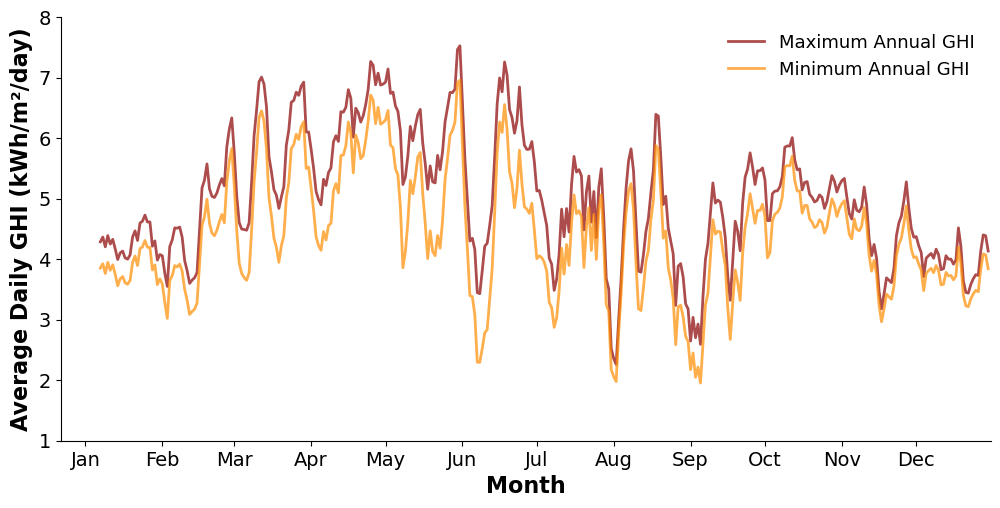

In [33]:
# Convert the day column to datetime format
district_daily_ghi['date'] = pd.to_datetime(district_daily_ghi['date'], format='mixed', dayfirst=False)

# Extract the GHI data for min, max, average districts
max_daily_ghi = district_daily_ghi[district_daily_ghi['district'] == max_district].copy()
min_daily_ghi = district_daily_ghi[district_daily_ghi['district'] == min_district].copy()
ave_daily_ghi = district_daily_ghi[district_daily_ghi['district'] == ave_district].copy()

# Calculate the rolling average for daily GHI over the course of the year
max_daily_ghi['ghi_rollavg'] = max_daily_ghi['daily_ghi_kwh/m2/day'].rolling(window=7).mean()
min_daily_ghi['ghi_rollavg'] = min_daily_ghi['daily_ghi_kwh/m2/day'].rolling(window=7).mean()
ave_daily_ghi['ghi_rollavg'] = ave_daily_ghi['daily_ghi_kwh/m2/day'].rolling(window=7).mean()

# Create a figure for each system size and axes for plotting all lines
fig, ax = plt.subplots(figsize=(12, 5.5))

# Plot each of the value columns against the day of year
# ax.plot(max_daily_ghi['date'], max_daily_ghi['global_solar_kw/m2'], 
#         color='orangered', alpha=0.7, linewidth=1, linestyle=':')
# ax.plot(min_daily_ghi['date'], min_daily_ghi['global_solar_kw/m2'], 
#         color='orange', alpha=0.7, linewidth=1, linestyle=':')
# ax.plot(ave_daily_ghi['date'], ave_daily_ghi['global_solar_kw/m2'], 
#         color='goldenrod', alpha=0.7, linewidth=1, linestyle=':')

# # Plot the 7 day rolling average
ax.plot(max_daily_ghi['date'], max_daily_ghi['ghi_rollavg'], 
        color='darkred', alpha=0.7, linewidth=2, label='Maximum Annual GHI')
# ax.plot(ave_daily_ghi['date'], ave_daily_ghi['ghi_rollavg'], 
#         color='darkorange', alpha=0.7, linewidth=2, label='Average Annual GHI')
ax.plot(min_daily_ghi['date'], min_daily_ghi['ghi_rollavg'], 
        color='darkorange', alpha=0.7, linewidth=2, label='Minimum Annual GHI')

# Format the x-axis to show only months
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Show numeric month (01 to 12)

# Set labels, title, and y limit
ax.set_xlabel('Month', fontsize=16, fontweight='bold')
ax.set_ylabel('Average Daily GHI (kWh/m\u00b2/day)', fontsize=16, fontweight='bold')
# ax.set_title(f'Total Number of Batteries Charged Per Day by 30 kW Charging System')

# Increase font size of tick labels
ax.tick_params(axis='both', which='major', labelsize=14)

# Set limits on the start and end of the year
start_date = pd.to_datetime(max_daily_ghi['date'].dt.to_period('Y').min().start_time)
end_date = pd.to_datetime(max_daily_ghi['date'].dt.to_period('Y').max().end_time) - pd.Timedelta(days=1)
# Add padding of ~6 days on each side (adjust as desired)
padding = timedelta(days=10)
ax.set_xlim([start_date - padding, end_date]) 
ax.set_ylim(1, round(max_daily_ghi['ghi_rollavg'].max() + 0.5))

# Define the border around the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

# # Clip spines to the first and last tick
# ax.spines['bottom'].set_bounds(ax.get_xticks()[0], ax.get_xticks()[-1])
ax.spines['left'].set_bounds(ax.get_yticks()[0], ax.get_yticks()[-1])

# Add a legend
plt.legend(fontsize=13, loc='upper right', frameon=False)
# plt.tight_layout()
plt.show()

/var/folders/x0/qnl8p2f174g_y6029kr9p3q80000gn/T/ipykernel_79335/590459943.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


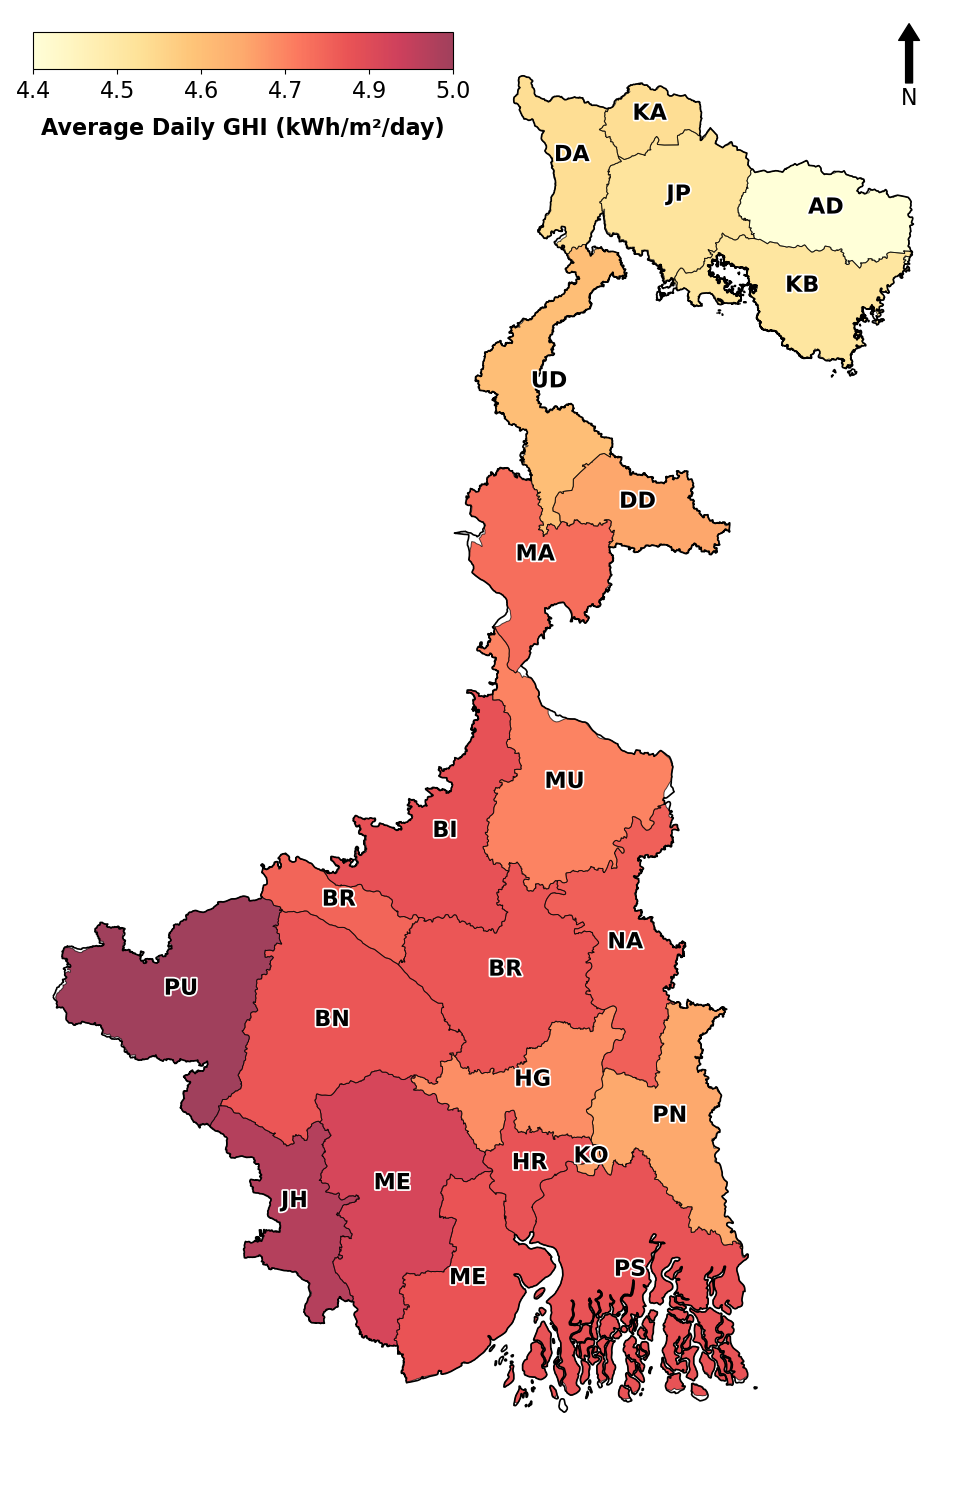

In [9]:
# Plot a spatial map of West Bengal districts with average daily GHI
fig, ax = plt.subplots(figsize=(15,15))

# Create a custom colormap
cmap = plt.get_cmap('YlOrRd')

# Get min and max of the column to set up a normalized color scale
vmin = wb_districts_avg_ghi['avg_ghi_kwh/m2/day'].min()
vmax = wb_districts_avg_ghi['avg_ghi_kwh/m2/day'].max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# Plot the boundaries
wb_districts_avg_ghi.plot(ax=ax, column='avg_ghi_kwh/m2/day', cmap=cmap, alpha=0.75)
wb_districts.boundary.plot(ax=ax, color='black', alpha=0.7, linewidth=0.7)
west_bengal.boundary.plot(ax=ax, color='black', linewidth=1.2)

# Add district code labels
for idx, row in wb_districts.iterrows():
    txt = ax.text(row.geometry.centroid.x, row.geometry.centroid.y, s=row['code'], 
             fontsize=16, fontweight='bold', ha='center', color='black')
    
    # Add a black outline around the text
    txt.set_path_effects([
        path_effects.Stroke(linewidth=2.5, foreground='white'),  # outline
        path_effects.Normal()  # normal text on top
    ])


# # Add a colorbar with a fixed position
# divider = make_axes_locatable(ax)
# cax = divider.append_axes("right", size="4%", pad=0.02)  # adjust pad for spacing

# Add a colorbar with the appropriate ticks and labels
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Only needed for older versions of Matplotlib

# Define number of ticks you want (including min and max)
n_ticks = 6
tick_values = np.linspace(vmin, vmax, n_ticks)

# Create the colorbar
# Manually position the colorbar (top left)
cax = fig.add_axes([0.2, 0.95, 0.28, 0.025])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', alpha=0.75)
cbar.set_ticks(tick_values)
cbar.set_ticklabels([f"{val:.1f}" for val in tick_values], fontsize=16)
cbar.ax.set_xlabel('Average Daily GHI (kWh/m\u00b2/day)', rotation=0, labelpad=10, fontsize=16, fontweight='bold')

# Add a basemap
# cx.add_basemap(ax, crs=west_bengal.crs, source=cx.providers.CartoDB.PositronNoLabels)

# Add a north arrow
x, y, arrow_length = 0.95, 0.99, 0.05        # adjust arrow position and arrow length
ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=16, xycoords=ax.transAxes)

# Remove latitude and longitude ticks
ax.set_xticks([])  # Remove x-axis (longitude) ticks
ax.set_yticks([])  # Remove y-axis (latitude) ticks
ax.axis('off')

# ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
# ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Change directory to output folder for CSVs with calculated PV sizes for each block
output_dir = "../data/output"
print(f'Output Directory: {output_dir}')

# Read in the csv files and create a compiled dataframe
pv_size_files = [f for f in os.listdir(output_dir) if f.endswith('.csv')]

# Create a list to store the dataframes
district_pv_sizes = []

# Loop through each file and read into a dataframe
for file in pv_size_files:
    # Read the CSV file into dataframe
    file_path = output_dir / file
    pv_df = pd.read_csv(file_path)

    # Append the dataframe to a list
    district_pv_sizes.append(pv_df)

# Create a new dataframe from the concatenated list
district_pv_df = pd.concat(district_pv_sizes, ignore_index=True)

# Merge the compiled block level PV sizes with the block geometry
merged_df = pd.merge(district_pv_df, block_fleet[['block', 'district', 'geometry']],
                     on=['block', 'district'], how='left')

# Conver the dataframe into GeoDataFrame
block_pv = gpd.GeoDataFrame(merged_df, geometry='geometry', crs=block_fleet.crs)

Output Directory: /Users/ahanamukherjee/Library/CloudStorage/OneDrive-UW/Research/04_E-Mobility/03_Data Collection/_West Bengal/_Data/_output


In [ ]:
# Save the PV sizes for each block based on each fleet conversion scenario
block_pv_10pct = block_pv[['block', 'district', 'geometry'] + [col for col in block_pv.columns if col.startswith('10%_conversion')]]
block_pv_30pct = block_pv[['block', 'district', 'geometry'] + [col for col in block_pv.columns if col.startswith('30%_conversion')]]
block_pv_100pct = block_pv[['block', 'district', 'geometry'] + [col for col in block_pv.columns if col.startswith('100%_conversion')]]

# Save as geoJSON files
block_pv_10pct.to_file('../data/processed/west-bengal-block-pv-10pct.geojson', driver='GeoJSON')
block_pv_30pct.to_file('../data/processed/west-bengal-block-pv-30pct.geojson', driver='GeoJSON')
block_pv_100pct.to_file('../data/processed/west-bengal-block-pv-100pct.geojson', driver='GeoJSON')

In [72]:
# Define a function calculate the decrease in PV energy production over system lifetime
def calc_pv_annual_energy_lifetime(df_pv, fleet_conversion='10%_conversion'):

    # Initialize the lifespan of the PV system (i.e. 25 years)
    years = list(range(26))

    # Create a dictionary to store the results of the decrease in annual PV production over lifespan of system
    lifetime_energy_prod = {'year': years}

    # Obtain a list of the block names
    block_id = df_pv['block'].unique()

    # Create a list storing the decrease in PV efficiency for each year of PV lifespan (based on SovaSolar module specifications, linear power percentage)
    efficiency = []
    for year in years:
        if year == 0:
            efficiency.append(1)
        elif year == 1:
            efficiency.append(0.975)
        else:
            efficiency.append(efficiency[-1] * (1 - 0.68/100))      # 0.68% efficiency decrease for every subsequent year

    # Loop through each file and read it into a DataFrame
    for block in block_id:

        # Extract the annual energy production for each block for Year 0 from previous sizing calculation
        annual_base_production = df_pv.loc[df_pv['block'] == block, f'{fleet_conversion}_annual_pv_energy'].values[0]

        # Calculate energy production over lifetime of PV with decreasing efficiency
        block_energy_prod = [annual_base_production * year_efficiency for year_efficiency in efficiency]

        # Store the results in a dictionary
        lifetime_energy_prod[block] = block_energy_prod

    # Create a new dataframe for the annual energy production at each district
    block_lifetime_energy = pd.DataFrame(lifetime_energy_prod)
    
    return block_lifetime_energy

In [ ]:
# Create compiled dataframe of annual PV energy decrease over system lifetime for all blocks
block_pv_energy_10pct = calc_pv_annual_energy_lifetime(block_pv_10pct, fleet_conversion='10%_conversion')
block_pv_energy_30pct = calc_pv_annual_energy_lifetime(block_pv_30pct, fleet_conversion='30%_conversion')
block_pv_energy_100pct = calc_pv_annual_energy_lifetime(block_pv_100pct, fleet_conversion='100%_conversion')

# Export out results
block_pv_energy_10pct.to_csv('../data/processed/block-pv-energy-lifetime-10pct.csv', index=False)
block_pv_energy_30pct.to_csv('../data/processed/block-pv-energy-lifetime-30pct.csv', index=False)
block_pv_energy_100pct.to_csv('../data/processed/block-pv-energy-lifetime-100pct.csv', index=False)

In [ ]:
# Read in the dataframes for PV sizes for each block for each fleet conversion scenario
pv_sizes_10pct = gpd.read_file('../data/processed/west-bengal-block-pv-10pct.geojson')
pv_sizes_30pct = gpd.read_file('../data/processed/west-bengal-block-pv-30pct.geojson')
pv_sizes_100pct = gpd.read_file('../data/processed/west-bengal-block-pv-100pct.geojson')

# Normalize the PV size for plotting
pv_sizes_10pct['pv_size_norm'] = np.log1p(pv_sizes_10pct['10%_conversion_pv_size'])
pv_sizes_30pct['pv_size_norm'] = np.log1p(pv_sizes_30pct['30%_conversion_pv_size'])
pv_sizes_100pct['pv_size_norm'] = np.log1p(pv_sizes_100pct['100%_conversion_pv_size'])

# Read in West Bengal districts with district codes
wb_districts = gpd.read_file('../data/processed/west-bengal-districts.geojson')

In [3]:
# Create a box-and-whisker plot for the aggregate PV size across each district
pv_district_10pct = pv_sizes_10pct.groupby('district')['10%_conversion_pv_size'].sum()
pv_district_30pct = pv_sizes_30pct.groupby('district')['30%_conversion_pv_size'].sum()
pv_district_100pct = pv_sizes_100pct.groupby('district')['100%_conversion_pv_size'].sum()

# Print the aggregate system capacity for Kolkata
print(f"Aggregate System Capacity Required for 10% conversion in Kolkata: {(pv_district_10pct['Kolkata'] / 1000):.3f} MW")
print(f"Aggregate System Capacity Required for 30% conversion in Kolkata: {(pv_district_30pct['Kolkata'] / 1000):.3f} MW")
print(f"Aggregate System Capacity Required for 100% conversion in Kolkata: {(pv_district_100pct['Kolkata'] / 1000):.3f} MW")

Aggregate System Capacity Required for 10% conversion in Kolkata: 6.318 MW
Aggregate System Capacity Required for 30% conversion in Kolkata: 16.648 MW
Aggregate System Capacity Required for 100% conversion in Kolkata: 52.806 MW


In [17]:
# Determine the min and max aggregate PV system sizes for each conversion scenario

# 10% conversion scenario
pv_sizes_10pct_nonzero = pv_sizes_10pct[pv_sizes_10pct['10%_conversion_pv_size'] != 0]
pv_sizes_10pct_nokol = pv_sizes_10pct[pv_sizes_10pct['block'] != 'Kolkata']
print(f"Minimum aggregate PV sizes (kW) for 10% fleet conversion scenario: {pv_sizes_10pct_nonzero['10%_conversion_pv_size'].min()} kW")
print(f"Maximum aggregate PV size (kW) for 10% fleet conversion scenario: {pv_sizes_10pct_nokol['10%_conversion_pv_size'].max()} kW")
print("")

# 30% conversion scenario
pv_sizes_30pct_nonzero = pv_sizes_30pct[pv_sizes_30pct['30%_conversion_pv_size'] != 0]
pv_sizes_30pct_nokol = pv_sizes_30pct[pv_sizes_30pct['block'] != 'Kolkata']
print(f"Minimum aggregate PV sizes (kW) for 10% fleet conversion scenario: {pv_sizes_30pct_nonzero['30%_conversion_pv_size'].min()} kW")
print(f"Maximum aggregate PV size (kW) for 10% fleet conversion scenario: {pv_sizes_30pct_nokol['30%_conversion_pv_size'].max()} kW")
print("")

# 100% conversion scenario
pv_sizes_100pct_nonzero = pv_sizes_100pct[pv_sizes_100pct['100%_conversion_pv_size'] != 0]
pv_sizes_100pct_nokol = pv_sizes_100pct[pv_sizes_100pct['block'] != 'Kolkata']
print(f"Minimum aggregate PV sizes (kW) for 10% fleet conversion scenario: {pv_sizes_100pct_nonzero['100%_conversion_pv_size'].min()} kW")
print(f"Maximum aggregate PV size (kW) for 10% fleet conversion scenario: {pv_sizes_100pct_nokol['100%_conversion_pv_size'].max()} kW")


Minimum aggregate PV sizes (kW) for 10% fleet conversion scenario: 8 kW
Maximum aggregate PV size (kW) for 10% fleet conversion scenario: 1311 kW

Minimum aggregate PV sizes (kW) for 10% fleet conversion scenario: 12 kW
Maximum aggregate PV size (kW) for 10% fleet conversion scenario: 3772 kW

Minimum aggregate PV sizes (kW) for 10% fleet conversion scenario: 14 kW
Maximum aggregate PV size (kW) for 10% fleet conversion scenario: 12387 kW


In [32]:
# Calculate the average swapping station system capacity for district with largest average system size
avg_cap_AD_10pct = pv_sizes_10pct[pv_sizes_10pct['district'] == 'Alipurduar']['10%_conversion_pv_size'].mean()
avg_cap_AD_30pct = pv_sizes_30pct[pv_sizes_30pct['district'] == 'Alipurduar']['30%_conversion_pv_size'].mean()
avg_cap_AD_100pct = pv_sizes_100pct[pv_sizes_100pct['district'] == 'Alipurduar']['100%_conversion_pv_size'].mean()

# Print the results
print(f'Average aggregate PV size for Alipurduar district for 10% fleet conversion scenario: {avg_cap_AD_10pct:.2f} kW')
print(f'Average aggregate PV size for Alipurduar district for 30% fleet conversion scenario: {avg_cap_AD_30pct:.2f} kW')
print(f'Average aggregate PV size for Alipurduar district for 100% fleet conversion scenario: {avg_cap_AD_100pct:.2f} kW')

Average aggregate PV size for Alipurduar district for 10% fleet conversion scenario: 419.50 kW
Average aggregate PV size for Alipurduar district for 30% fleet conversion scenario: 537.83 kW
Average aggregate PV size for Alipurduar district for 100% fleet conversion scenario: 947.50 kW


In [36]:
# Process aggregate PV sizes for each conversion scenario for plotting
pv_sizes_all = {
    '10%': pv_sizes_10pct,
    '30%': pv_sizes_30pct,
    '100%': pv_sizes_100pct
}

# Define a new dictionary to store aggregate PV sizes without Kolkata
pv_sizes_filter = {}

for scenario, df in pv_sizes_all.items():
    # Define the prefix to eliminate in column headers for all dataframes
    prefix = f"{scenario}_conversion_"

    # Remove the prefix from column headers in dataframe
    df_clean = df.copy()      # Create a copy of the original dataframe
    df_clean = df_clean.rename(
        columns= lambda col_name: col_name.replace(prefix, "") if prefix in col_name else col_name)
    
    # Add a column for the scenario column in the dataframe
    df_clean['scenario'] = f"{scenario} conversion"

    # Add district codes for all block
    df_clean = df_clean.merge(
        wb_districts[['district', 'code']],
        on='district',
        how='left')

    # Drop Kolkata from the dataframe
    df_clean = df_clean[df_clean['district'] != 'Kolkata']

    # Add cleaned dataframe to new dictionary
    pv_sizes_filter[scenario] = df_clean

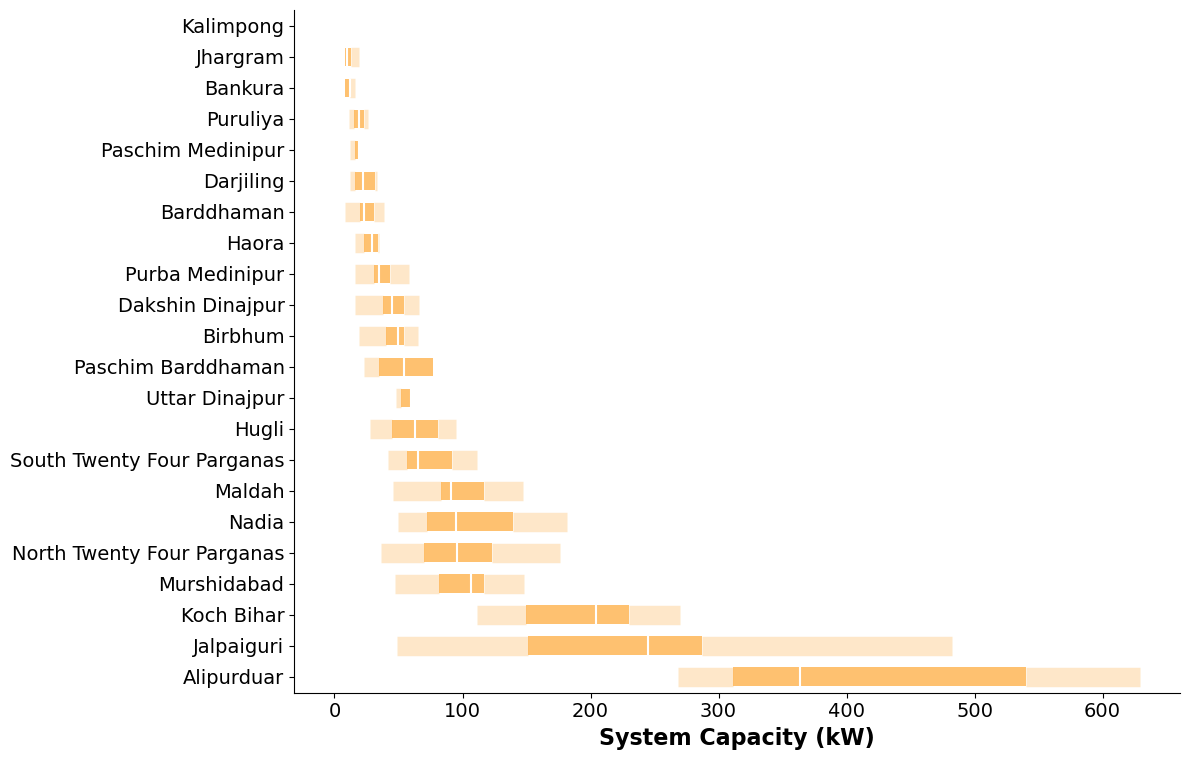

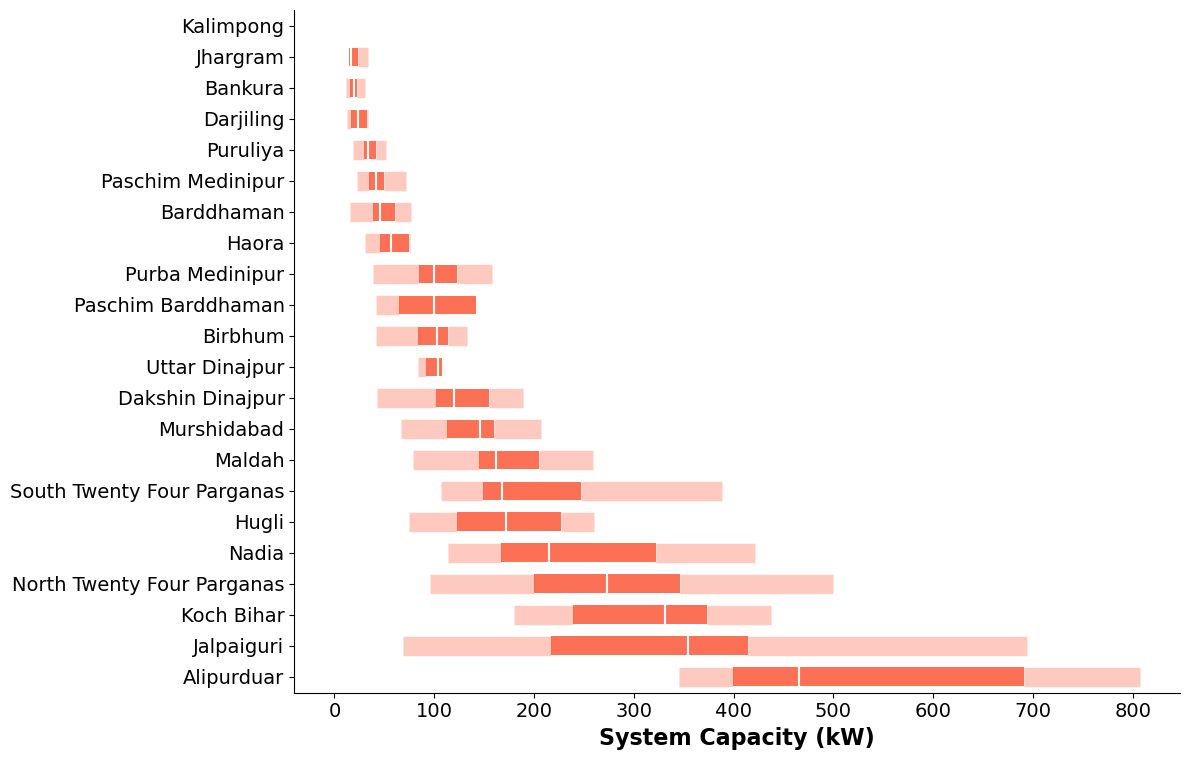

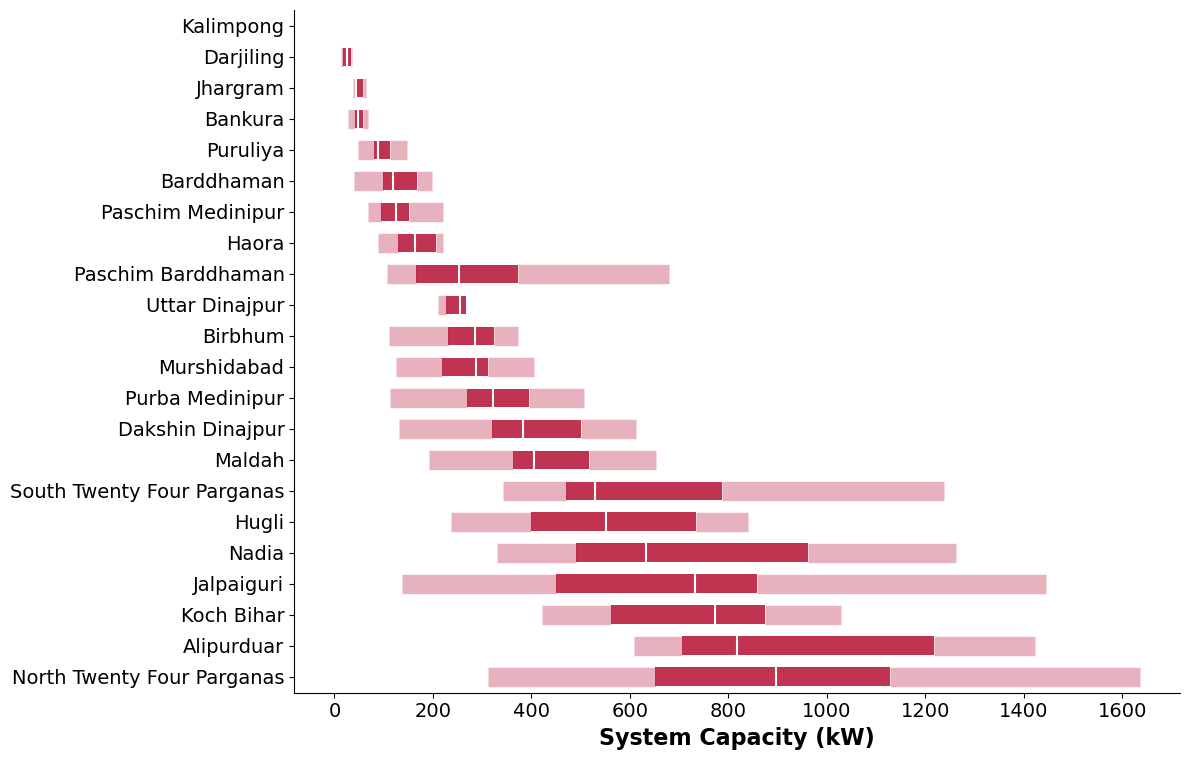

In [ ]:
# Combine all scenarios into one dataframe
pv_combine = pd.concat(pv_sizes_filter.values(), ignore_index=True)

# Define the colors for each plot
scenario_colors = {
    '10%': '#feb24c',   # blue
    '30%': '#fc4e2a',   # orange
    '100%': '#b10026'   # green
}

for scenario, df in pv_sizes_filter.items():
    # Compute total aggregate PV size per district for specific scenario to define order in plot
    district_order = (
        df.groupby('district')['pv_size']
        .median()
        .sort_values(ascending=True)  # smallest at top, largest at bottom
        .index
    )

    # Create the boxplot
    fig, ax = plt.subplots(figsize=(12, len(district_order) * 0.35))
    ax = sns.boxplot(
        data=df,
        y='district',
        x='pv_size',
        order=district_order,     # order districts by median
        orient='h',
        width=0.6,
        showfliers=False,              # hide outliers
        color=scenario_colors[scenario],
        linewidth=0,                   # remove black outlines
        boxprops=dict(facecolor=scenario_colors[scenario], alpha=0.8),  # softer color, no edges
        whiskerprops=dict(color=scenario_colors[scenario], alpha=0.3, linewidth=14), # thicker “bar-style” whiskers
        capprops=dict(color=scenario_colors[scenario], linewidth=0),     # Remove caps
        medianprops=dict(color='white', linewidth=1.5)   # white median line
    )

    # Optional: shrink spacing even more (remove padding around plot)
    plt.margins(y=0.01)  # smaller margin between boxes and plot edge

    # Increase font size of tick labels
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Define the border around the plot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

    # Customize appearance
    ax.set_xlabel('System Capacity (kW)', fontsize=16, fontweight='bold')
    ax.set_ylabel('')
    # plt.legend(title='Scenario', loc='upper right', frameon=True)
    plt.tight_layout()
    plt.show()

/var/folders/x0/qnl8p2f174g_y6029kr9p3q80000gn/T/ipykernel_1691/780342059.py:74: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(new_labels)


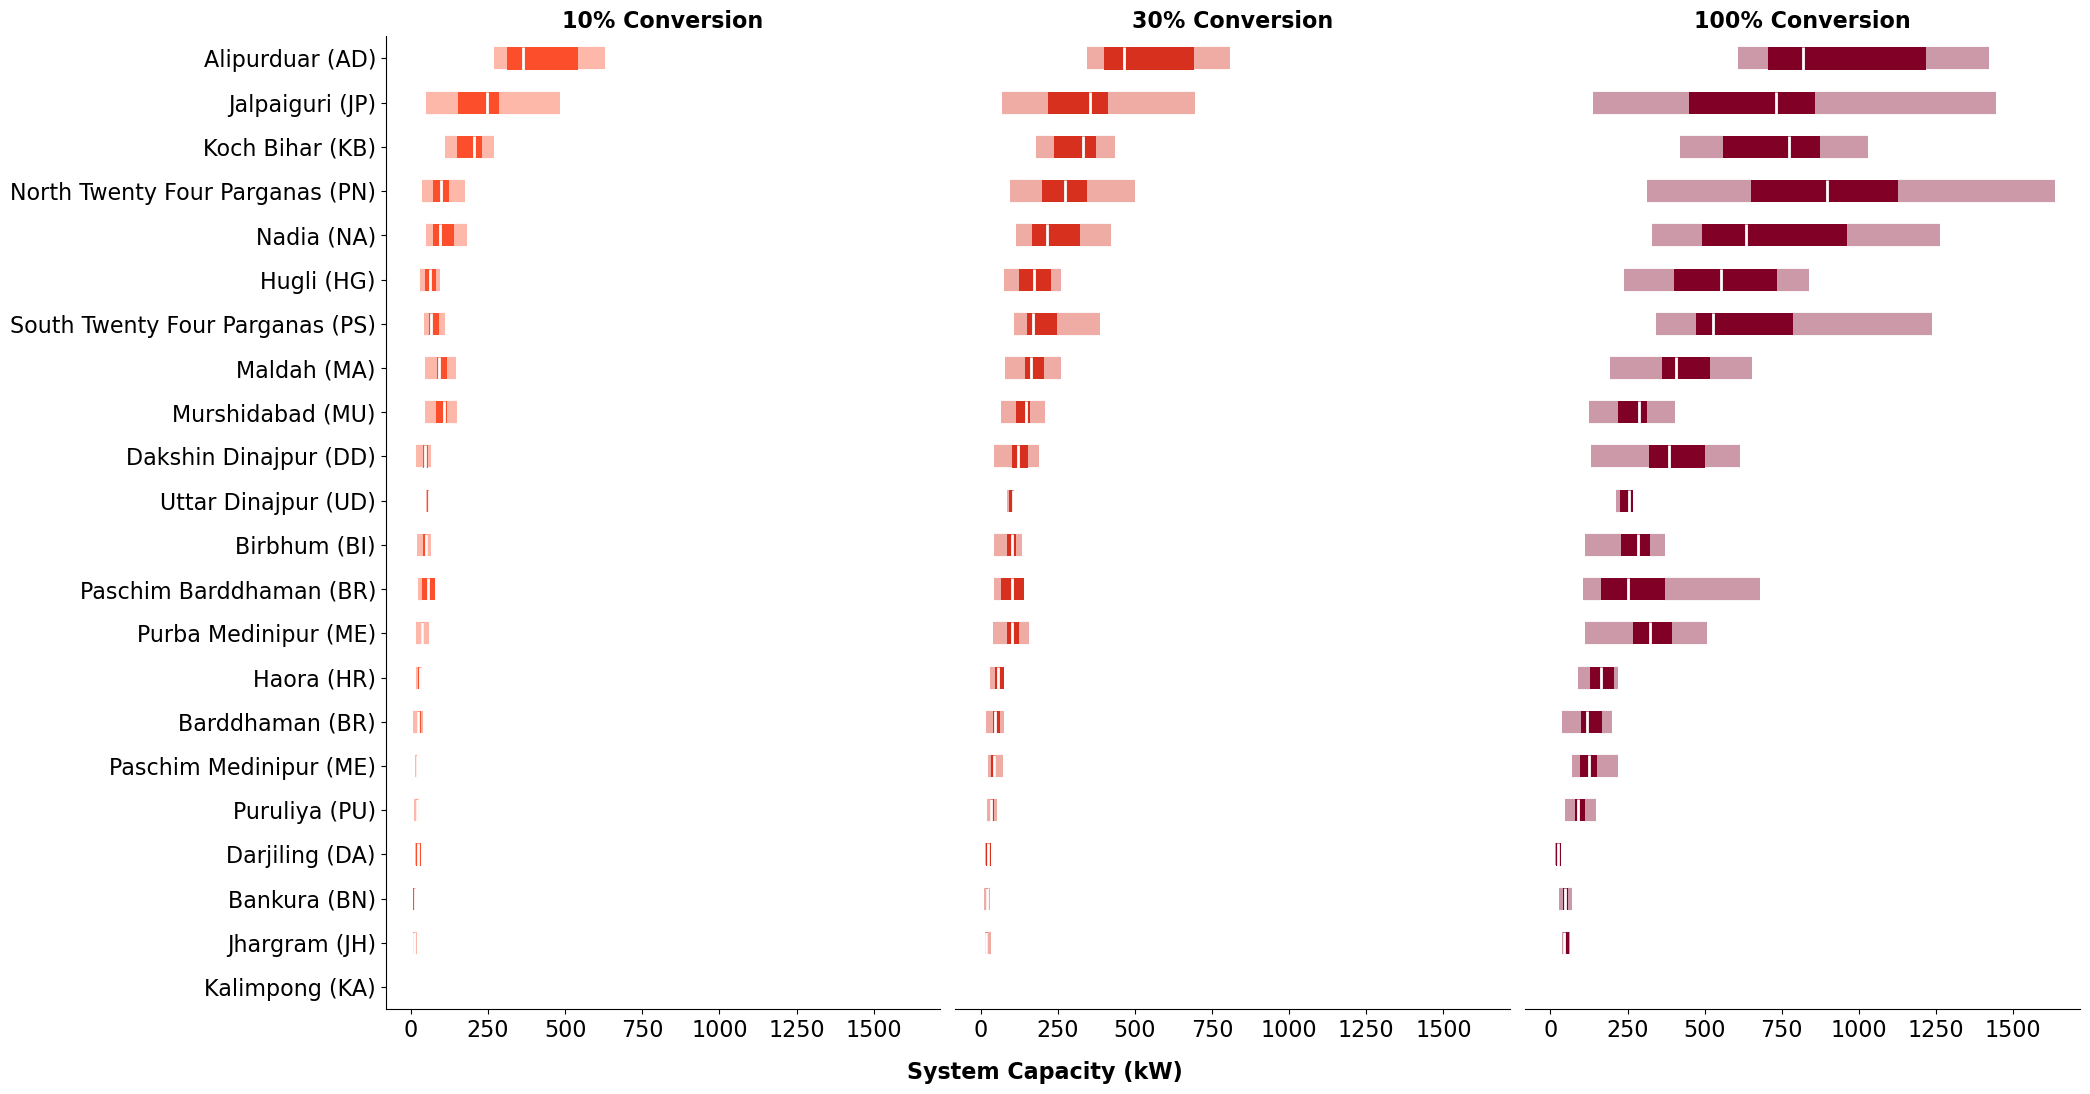

In [53]:
# Combine all scenarios into one dataframe
pv_combine = pd.concat(pv_sizes_filter.values(), ignore_index=True)

# Define the colors for each plot
scenario_colors = {
    '10%': '#fc4e2a',
    '30%': '#d7301f',
    '100%': '#800026'
}

# Determine the order of districts (use one scenario or combined medians)
district_order = (
    pv_sizes_filter['30%'].groupby('district')['pv_size']
    .median()
    .sort_values(ascending=False)
    .index
)

# Create a single row of subplots
scenarios = list(pv_sizes_filter.keys())
n_scenarios = len(scenarios)

fig, axes = plt.subplots(
    1, n_scenarios,
    figsize=(7 * n_scenarios, len(district_order) * 0.5),
    sharey=True,
    sharex=True
)

# If only one scenario, axes is not iterable
if n_scenarios == 1:
    axes = [axes]

# Loop through scenarios and plot each in its own subplot
for ax, scenario in zip(axes, scenarios):
    df = pv_sizes_filter[scenario]

    # Plot the box-and-whisker plot
    sns.boxplot(
        data=df,
        y=f'district',
        x='pv_size',
        order=district_order,
        orient='h',
        width=0.5,
        showfliers=False,
        color=scenario_colors[scenario],
        linewidth=0,
        boxprops=dict(facecolor=scenario_colors[scenario], alpha=1),
        whiskerprops=dict(color=scenario_colors[scenario], alpha=0.4, linewidth=16),
        capprops=dict(color=scenario_colors[scenario], linewidth=0),
        medianprops=dict(color='white', linewidth=2),
        ax=ax
    )

    ax.set_title(f'{scenario} Conversion', fontsize=16, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', which='major', labelsize=16)

    if ax == axes[0]:
        # Create a lookup table with both district and code
        df_labels = df[['district', 'code']].copy()

        # Create combined labels
        df_labels['district_label'] = df_labels['district'] + ' (' + df_labels['code'] + ')'

        # Use the district order to define label order
        label_map = df_labels.drop_duplicates(subset=['district']).set_index('district')['district_label']

        # Apply the labels in the correct order
        new_labels = [label_map.get(dist, dist) for dist in district_order]

        ax.set_yticklabels(new_labels)
    else:
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    # Hide y-axis labels and ticks for all but the first plot
    if ax != axes[0]:
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    # Clean up borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(ax == axes[0])  # only show y-axis on first plot

# Add a common x-axis label
fig.supxlabel('System Capacity (kW)', fontsize=16, fontweight='bold')

# Tight layout and show
plt.tight_layout()
plt.show()